# Experiment — binary CNN1D classifier with K-fold CV

A purely convolutional binary classifier (no recurrent layer), evaluated with a full Optuna + StratifiedGroupKFold protocol.

**Best validation weighted-F1: 0.9586** on the low/high subproblem. The CNN-GRU variant was preferred for the final gate because it shares its structure with the main classifier, which made the logit fusion better behaved.

---


## Google Drive Connection


In [ ]:
# --- Paths ---------------------------------------------------------------
# Originally executed on Google Colab with the dataset on Google Drive.
# DATA_DIR must contain: pirate_pain_train.csv, pirate_pain_train_labels.csv,
# pirate_pain_test.csv, sample_submission.csv  (see data/README.md)
import os

DATA_DIR = os.environ.get("PIRATE_DATA_DIR", "data")
os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)


## Libraries Import


In [3]:
# @title
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
# from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, Dataset, DataLoader, WeightedRandomSampler
logs_dir = "tensorboard"
%load_ext tensorboard
!mkdir -p models

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

from sklearn.model_selection import StratifiedGroupKFold

import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.cuda.amp import GradScaler
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

PyTorch version: 2.8.0+cu126
Device: cuda


## Data Preprocessing


In [4]:
# Define the window size
WINDOW_SIZE = 200

# Define the stride for overlapping windows
STRIDE = 50

# Define the batch size
BATCH_SIZE = 64

In [5]:
# -----------------------
# Load datasets
# -----------------------
X_train = pd.read_csv('../Dataset/pirate_pain_train.csv')
y_train = pd.read_csv('../Dataset/pirate_pain_train_labels.csv')
X_test  = pd.read_csv('../Dataset/pirate_pain_test.csv')

# -----------------------
# Drop missing values
# -----------------------
X_train.dropna(inplace=True)
y_train.dropna(inplace=True)
X_test.dropna(inplace=True)

# -----------------------
# Map static features to integers
# -----------------------
legs_mapping  = {'two': 2, 'one+peg_leg': 1}
hands_mapping = {'two': 2, 'one+hook_hand': 1}
eyes_mapping  = {'two': 2, 'one+eye_patch': 1}

for df in [X_train, X_test]:
    df['n_legs']  = df['n_legs'].map(legs_mapping)
    df['n_hands'] = df['n_hands'].map(hands_mapping)
    df['n_eyes']  = df['n_eyes'].map(eyes_mapping)

# -----------------------
# Merge labels and filter only low/high pain
# -----------------------
df_full = X_train.merge(y_train, on='sample_index')
df_full = df_full[df_full['label'].isin(['low_pain','high_pain'])]

X_train = df_full.drop(columns=['label'])
y_train = df_full[['sample_index','label']]

# -----------------------
# Drop columns with only one unique value
# -----------------------
cols_to_drop = [col for col in X_train.columns if X_train[col].nunique() == 1]
X_train.drop(columns=cols_to_drop, inplace=True)

# -----------------------
# Map labels to integers
# -----------------------
label_mapping = {'low_pain': 0, 'high_pain': 1}
y_train['label'] = y_train['label'].map(label_mapping)

# -----------------------
# Convert joint columns to float32
# -----------------------
num_joints = 29
joint_cols = [f'joint_{i:02d}' for i in range(num_joints+1)]
for col in joint_cols:
    X_train[col] = X_train[col].astype(np.float32)
    X_test[col]  = X_test[col].astype(np.float32)

# -----------------------
# StratifiedGroupKFold split
# -----------------------
df_subjects = X_train[['sample_index']].drop_duplicates().merge(y_train, on='sample_index')
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_idx, val_idx = next(sgkf.split(df_subjects, df_subjects['label'], groups=df_subjects['sample_index']))

train_users = df_subjects.iloc[train_idx]['sample_index'].values
val_users   = df_subjects.iloc[val_idx]['sample_index'].values

df_train = X_train[X_train['sample_index'].isin(train_users)]
df_val   = X_train[X_train['sample_index'].isin(val_users)]

# -----------------------
# Z-score normalization on dynamic features
# -----------------------
pain_survey_cols = [f'pain_survey_{i+1}' for i in range(4)]
dyn_cols = pain_survey_cols + joint_cols

means = df_train[dyn_cols].mean()
stds  = df_train[dyn_cols].std()

for df in [df_train, df_val]:
    df[dyn_cols] = (df[dyn_cols] - means) / (stds + 1e-8)

# -----------------------
# Data augmentation function
# -----------------------
def augment_sequence(X_seq, noise_std=0.01, scale_sigma=0.05, max_shift=5, slice_ratio=0.9):
    """Augmentation for CNN1D sequences: noise, scaling, shift and slicing.
    """X_aug = X_seq.copy()
    window, n_features = X_aug.shape

    # 1. Gaussian noise
    X_aug += np.random.normal(0, noise_std, X_aug.shape)

    # 2. Magnitude scaling
    factor = np.random.normal(1.0, scale_sigma)
    X_aug *= factor

    # 3. Random time shift
    shift = np.random.randint(-max_shift, max_shift + 1)
    if shift > 0:
        X_aug = np.vstack([X_aug[shift:], np.tile(X_aug[-1:], (shift, 1))])
    elif shift < 0:
        X_aug = np.vstack([np.tile(X_aug[:1], (-shift, 1)), X_aug[:shift]])

    # 4. Random cropping + padding
    if slice_ratio < 1.0:
        new_len = int(window * slice_ratio)
        start_idx = np.random.randint(0, window - new_len + 1)
        X_aug = X_aug[start_idx:start_idx + new_len]
        pad_len = window - new_len
        X_aug = np.pad(X_aug, ((0, pad_len), (0, 0)), mode='edge')

    return X_aug.astype('float32')

# -----------------------
# Build sequences function
# -----------------------
def build_sequences(df, y_df=None, window=WINDOW_SIZE, stride=STRIDE, is_test=False, augment=False):
    static_cols = ['n_legs','n_hands','n_eyes']
    dyn_cols = pain_survey_cols + joint_cols
    X_seq, X_static, y_seq = [], [], []

    for sid in df['sample_index'].unique():
        temp = df[df['sample_index']==sid]
        static_vals = temp[static_cols].iloc[0].values.astype('float32')
        dyn_vals = temp[dyn_cols].values.astype('float32')

        pad_len = (window - len(dyn_vals) % window) % window
        if pad_len > 0:
            dyn_vals = np.pad(dyn_vals, ((0,pad_len),(0,0)), mode='edge')

        idx = 0
        while idx + window <= len(dyn_vals):
            seq_window = dyn_vals[idx:idx+window]
            if augment and not is_test:
                seq_window = augment_sequence(seq_window)
            X_seq.append(seq_window)
            X_static.append(static_vals)
            if not is_test:
                label = y_df[y_df['sample_index']==sid]['label'].values[0]
                y_seq.append(label)
            idx += stride

    X_seq = np.array(X_seq, dtype='float32')
    X_static = np.array(X_static, dtype='float32')
    y_seq = np.array(y_seq, dtype='int64') if not is_test else None
    return (X_seq, X_static, y_seq) if not is_test else (X_seq, X_static)

# -----------------------
# Create sequences
# -----------------------
X_train_seq, X_train_static, y_train_seq = build_sequences(df_train, y_train, augment=True)
X_val_seq, X_val_static, y_val_seq     = build_sequences(df_val, y_train, augment=False)

input_size_dynamic=X_train_seq.shape[-1]
input_size_static=X_train_static.shape[1]

# -----------------------
# PyTorch Dataset
# -----------------------
class PirateDataset(Dataset):
    def __init__(self, X_seq, X_static, y=None):
        self.X_seq = torch.from_numpy(X_seq).float()
        self.X_static = torch.from_numpy(X_static).float()
        self.y = torch.from_numpy(y).long() if y is not None else None
    def __len__(self):
        return len(self.X_seq)
    def __getitem__(self, idx):
        return (self.X_seq[idx], self.X_static[idx], self.y[idx]) if self.y is not None else (self.X_seq[idx], self.X_static[idx])

# -----------------------
# DataLoader with weighted sampler
# -----------------------
def make_loader(ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False):
    cpu_cores = os.cpu_count() or 2
    num_workers = max(2, min(4, cpu_cores))

    sampler = None
    if hasattr(ds,"y") and ds.y is not None and shuffle:
        labels = ds.y.numpy()
        class_counts = np.bincount(labels)
        class_weights = 1.0 / (class_counts + 1e-9)
        sample_weights = class_weights[labels]
        sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)
        shuffle=False

    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last,
                      num_workers=num_workers, pin_memory=True, sampler=sampler)

# -----------------------
# Create loaders
# -----------------------
train_ds = PirateDataset(X_train_seq, X_train_static, y_train_seq)
val_ds   = PirateDataset(X_val_seq, X_val_static, y_val_seq)

train_loader = make_loader(train_ds, shuffle=True)
val_loader   = make_loader(val_ds, shuffle=False)

## Model Building


In [6]:
class CNN1D_Binary(nn.Module):
    def __init__(self, input_dyn, input_static, num_classes=2, dropout=0.3):
        super().__init__()

        # ---------------------
        # CNN over the dynamic channels
        # ---------------------
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=input_dyn, out_channels=64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.MaxPool1d(kernel_size=2),

            nn.Conv1d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.AdaptiveAvgPool1d(1)  # output: (batch, 128, 1)
        )

        # ---------------------
        # MLP over the static features
        # ---------------------
        self.fc_static = nn.Sequential(
            nn.Linear(input_static, 32),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # ---------------------
        # Classifier finale
        # ---------------------
        self.fc_final = nn.Sequential(
            nn.Linear(128 + 32, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x_dyn, x_static):
        # x_dyn: (batch, seq_len, features) -> Conv1d expects (batch, features, seq_len)
        x_dyn = x_dyn.permute(0, 2, 1)
        x_dyn = self.cnn(x_dyn)
        x_dyn = x_dyn.squeeze(-1)  # (batch, 128)

        x_static = self.fc_static(x_static)  # (batch, 32)

        x = torch.cat([x_dyn, x_static], dim=1)
        logits = self.fc_final(x)
        return logits

## Training Functions


In [7]:
def train_one_epoch(model, train_loader, criterion, optimizer, scaler, device, l1_lambda=0):
    """Perform one training epoch including static features and L1 regularization.
    """
    model.train()
    running_loss = 0.0
    all_predictions, all_targets = [], []

    for inputs, x_static, targets in train_loader:
        inputs = inputs.to(device).float()
        x_static = x_static.to(device).float()
        targets = targets.to(device)

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast(device_type=device.type, enabled=(device.type=='cuda')):
            logits = model(inputs, x_static)
            loss = criterion(logits, targets)

            # L1 regularization
            if l1_lambda > 0:
                l1_norm = sum(p.abs().sum() for p in model.parameters())
                loss += l1_lambda * l1_norm

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * inputs.size(0)
        all_predictions.append(logits.argmax(dim=1).cpu().numpy())
        all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_f1 = f1_score(np.concatenate(all_targets), np.concatenate(all_predictions), average='weighted')

    return epoch_loss, epoch_f1

In [8]:
def validate_one_epoch(model, val_loader, criterion, device):
    """Perform one validation epoch including static features.
    """
    model.eval()
    running_loss = 0.0
    all_predictions, all_targets = [], []

    with torch.no_grad():
        for inputs, x_static, targets in val_loader:
            inputs = inputs.to(device).float()
            x_static = x_static.to(device).float()
            targets = targets.to(device)

            with torch.amp.autocast(device_type=device.type, enabled=(device.type=='cuda')):
                logits = model(inputs, x_static)
                loss = criterion(logits, targets)

            running_loss += loss.item() * inputs.size(0)
            all_predictions.append(logits.argmax(dim=1).cpu().numpy())
            all_targets.append(targets.cpu().numpy())

    epoch_loss = running_loss / len(val_loader.dataset)
    epoch_f1 = f1_score(np.concatenate(all_targets), np.concatenate(all_predictions), average='weighted')

    return epoch_loss, epoch_f1

In [9]:
def log_metrics_to_tensorboard(writer, epoch, train_loss, train_f1, val_loss, val_f1, model):
    """Log scalar metrics and histograms for model weights and gradients.
    """
    writer.add_scalar('Loss/Training', train_loss, epoch)
    writer.add_scalar('Loss/Validation', val_loss, epoch)
    writer.add_scalar('F1/Training', train_f1, epoch)
    writer.add_scalar('F1/Validation', val_f1, epoch)

    for name, param in model.named_parameters():
        if param.requires_grad:
            if param.numel() > 0:
                writer.add_histogram(f'{name}/weights', param.data, epoch)
            if param.grad is not None and param.grad.numel() > 0:
                writer.add_histogram(f'{name}/gradients', param.grad.data, epoch)

In [16]:
def fit(model, train_loader, val_loader, epochs, criterion, optimizer, scaler, device,
        l1_lambda=0, l2_lambda=0, patience=0, evaluation_metric="val_f1", mode='max',
        restore_best_weights=True, writer=None, verbose=10, experiment_name="", base_path="", scheduler=None):

    """Train the model with optional early stopping, scheduler, TensorBoard logging.
    This version works even if val_loader=None (no validation set).
    """

    training_history = {
        'train_loss': [],
        'train_f1': [],
    }

    # Only create val keys if validation exists
    if val_loader is not None:
        training_history['val_loss'] = []
        training_history['val_f1'] = []

    # Early stopping only applied if validation exists
    use_early_stopping = (val_loader is not None and patience > 0)

    if use_early_stopping:
        patience_counter = 0
        best_metric = float('-inf') if mode == 'max' else float('inf')
        best_epoch = 0

    # Ensure model save directory exists
    os.makedirs(base_path + "models/", exist_ok=True)

    print(f"Training {epochs} epochs...")

    for epoch in range(1, epochs + 1):

        # -----------------------------
        #         TRAINING
        # -----------------------------
        train_loss, train_f1 = train_one_epoch(
            model, train_loader, criterion, optimizer, scaler, device, l1_lambda
        )

        training_history['train_loss'].append(train_loss)
        training_history['train_f1'].append(train_f1)

        # -----------------------------
        #       VALIDATION (optional)
        # -----------------------------
        if val_loader is not None:
            val_loss, val_f1 = validate_one_epoch(
                model, val_loader, criterion, device
            )
            training_history['val_loss'].append(val_loss)
            training_history['val_f1'].append(val_f1)

            # Scheduler uses validation metric
            if scheduler is not None:
                metric_to_track = val_f1 if evaluation_metric == "val_f1" else val_loss
                scheduler.step(metric_to_track)

        else:
            # No validation → scheduler steps on train loss only
            if scheduler is not None:
                scheduler.step(train_loss)

        # -----------------------------
        #       PRINTING
        # -----------------------------
        if verbose > 0 and (epoch % verbose == 0 or epoch == 1):
            if val_loader is None:
                print(f"Epoch {epoch:3d}/{epochs} | Train: Loss={train_loss:.4f}, F1={train_f1:.4f}")
            else:
                print(f"Epoch {epoch:3d}/{epochs} | "
                      f"Train: Loss={train_loss:.4f}, F1={train_f1:.4f} | "
                      f"Val: Loss={val_loss:.4f}, F1={val_f1:.4f}")

        # -----------------------------
        #       EARLY STOPPING
        # -----------------------------
        if use_early_stopping:
            current_metric = training_history[evaluation_metric][-1]  # val_f1 or val_loss

            is_improvement = (
                current_metric > best_metric if mode == 'max'
                else current_metric < best_metric
            )

            if is_improvement:
                best_metric = current_metric
                best_epoch = epoch
                torch.save(
                    model.state_dict(),
                    base_path + "models/" + experiment_name + '_model.pt'
                )
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience:
                    print(f"Early stopping triggered after {epoch} epochs.")
                    break

    # -----------------------------
    #     RESTORE BEST WEIGHTS
    # -----------------------------
    if use_early_stopping and restore_best_weights:
        model.load_state_dict(torch.load(
            base_path + "models/" + experiment_name + '_model.pt'
        ))
        print(f"Best model restored from epoch {best_epoch} with {evaluation_metric}={best_metric:.4f}")

    # -----------------------------
    #      SAVE FINAL MODEL
    # -----------------------------
    if not use_early_stopping:
        torch.save(
            model.state_dict(),
            base_path + "models/" + experiment_name + '_model.pt'
        )

    if writer is not None:
        writer.close()

    return model, training_history

## Model Training


In [11]:
# Initialize best model tracking variables
best_model = None
best_performance = float('-inf')

In [12]:
LEARNING_RATE = 2e-4
EPOCHS = 200
PATIENCE = 30
DROPOUT_RATE = 0.35
L2_LAMBDA = 1e-3

model = CNN1D_Binary(
    input_dyn=input_size_dynamic,
    input_static=input_size_static,
    dropout=DROPOUT_RATE
).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=L2_LAMBDA
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.3, patience=10
)

scaler = torch.amp.GradScaler(enabled=(device.type=='cuda'))

experiment_name = "cnn1d_bin"

model, training_history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=None,
    verbose=1,
    experiment_name=experiment_name,
    patience=PATIENCE,
    base_path="",
    scheduler=scheduler
)

Training 200 epochs...
Epoch   1/200 | Train: Loss=0.6962, F1=0.4724 | Val: Loss=0.7013, F1=0.3333
Epoch   2/200 | Train: Loss=0.6440, F1=0.6267 | Val: Loss=0.7005, F1=0.3333
Epoch   3/200 | Train: Loss=0.6668, F1=0.5395 | Val: Loss=0.6987, F1=0.3333
Epoch   4/200 | Train: Loss=0.6033, F1=0.7328 | Val: Loss=0.6964, F1=0.3333
Epoch   5/200 | Train: Loss=0.6493, F1=0.6269 | Val: Loss=0.6935, F1=0.3333
Epoch   6/200 | Train: Loss=0.6079, F1=0.6538 | Val: Loss=0.6897, F1=0.4034
Epoch   7/200 | Train: Loss=0.5537, F1=0.8328 | Val: Loss=0.6848, F1=0.4665
Epoch   8/200 | Train: Loss=0.5480, F1=0.8582 | Val: Loss=0.6798, F1=0.5764
Epoch   9/200 | Train: Loss=0.5412, F1=0.8751 | Val: Loss=0.6753, F1=0.5764
Epoch  10/200 | Train: Loss=0.5533, F1=0.7908 | Val: Loss=0.6698, F1=0.6250
Epoch  11/200 | Train: Loss=0.4892, F1=0.8241 | Val: Loss=0.6631, F1=0.6827
Epoch  12/200 | Train: Loss=0.4960, F1=0.8999 | Val: Loss=0.6553, F1=0.6827
Epoch  13/200 | Train: Loss=0.4737, F1=0.9084 | Val: Loss=0.6448,

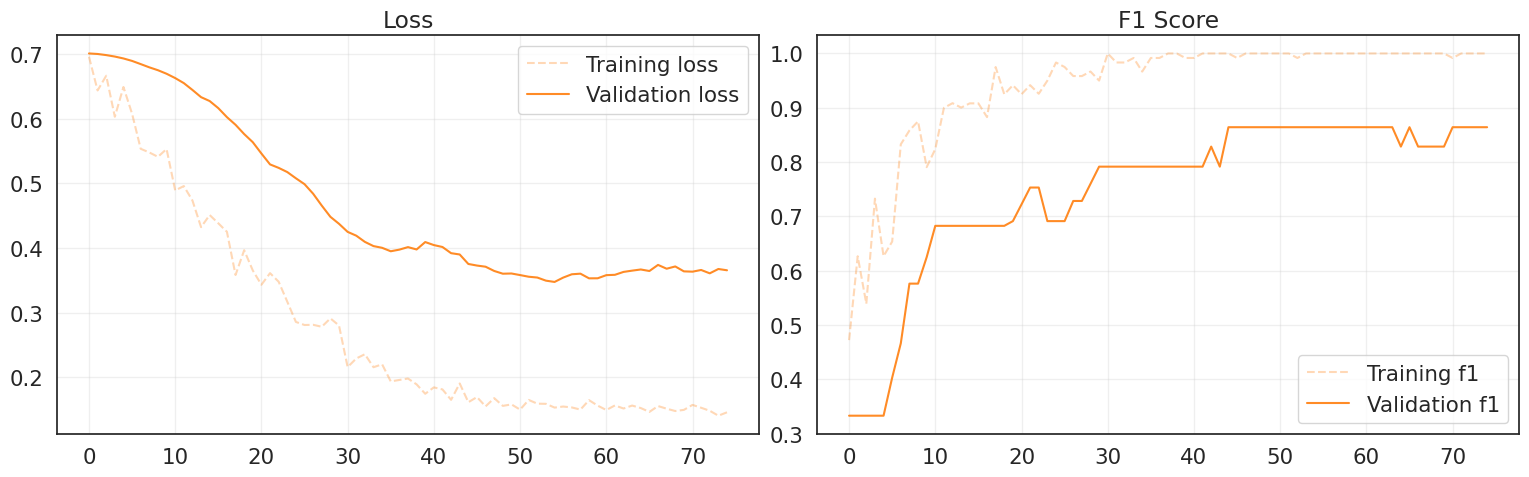

In [13]:
# Create a figure with two side-by-side subplots (two columns)
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(18, 5))

# Plot of training and validation loss on the first axis
ax1.plot(training_history['train_loss'], label='Training loss', alpha=0.3, color='#ff7f0e', linestyle='--')
ax1.plot(training_history['val_loss'], label='Validation loss', alpha=0.9, color='#ff7f0e')
ax1.set_title('Loss')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot of training and validation accuracy on the second axis
ax2.plot(training_history['train_f1'], label='Training f1', alpha=0.3, color='#ff7f0e', linestyle='--')
ax2.plot(training_history['val_f1'], label='Validation f1', alpha=0.9, color='#ff7f0e')
ax2.set_title('F1 Score')
ax2.legend()
ax2.grid(alpha=0.3)

# Adjust the layout and display the plot
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

Accuracy over the validation set: 0.8667
Precision over the validation set: 0.8947
Recall over the validation set: 0.8667
F1 score over the validation set: 0.8643


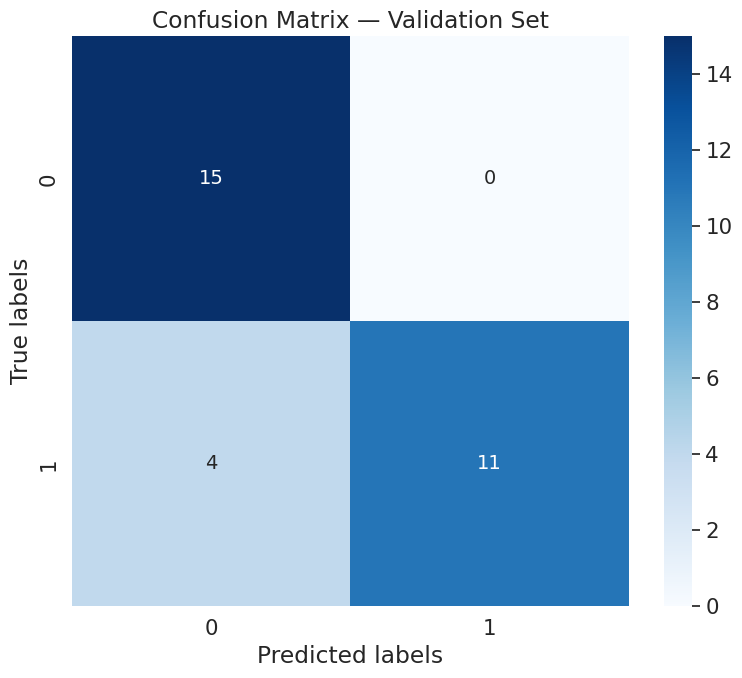

In [14]:
# Collect predictions and ground truth labels
val_preds, val_targets = [], []

with torch.no_grad():  # Disable gradient computation
    for xb_dyn, xb_static, yb in val_loader:
        # Move data to device
        xb_dyn = xb_dyn.to(device).float()
        xb_static = xb_static.to(device).float()
        yb = yb.to(device)

        # Forward pass: get model predictions
        logits = model(xb_dyn, xb_static)
        preds = logits.argmax(dim=1).cpu().numpy()

        # Store batch results
        val_preds.append(preds)
        val_targets.append(yb.cpu().numpy())

# Combine all batches into single arrays
val_preds = np.concatenate(val_preds)
val_targets = np.concatenate(val_targets)

# Calculate overall validation metrics
val_acc = accuracy_score(val_targets, val_preds)
val_prec = precision_score(val_targets, val_preds, average='weighted')
val_rec = recall_score(val_targets, val_preds, average='weighted')
val_f1 = f1_score(val_targets, val_preds, average='weighted')

print(f"Accuracy over the validation set: {val_acc:.4f}")
print(f"Precision over the validation set: {val_prec:.4f}")
print(f"Recall over the validation set: {val_rec:.4f}")
print(f"F1 score over the validation set: {val_f1:.4f}")

# Generate confusion matrix for detailed error analysis
cm = confusion_matrix(val_targets, val_preds)

# Create numeric labels for heatmap annotation
labels = np.array([f"{num}" for num in cm.flatten()]).reshape(cm.shape)

# Visualize confusion matrix
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix — Validation Set')
plt.tight_layout()
plt.show()

## StratifiedGroupKFold and Random Splits


In [15]:
# from sklearn.model_selection import StratifiedGroupKFold
# from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
# import numpy as np
# import torch

# N_SPLITS = 5
# N_REPEATS = 3
# SEED = 42

# all_metrics = []
# subjects = df_subjects['sample_index'].values
# labels = df_subjects['label'].values

# for repeat in range(N_REPEATS):
#     sgkf = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED + repeat)

#     for fold, (train_idx, val_idx) in enumerate(sgkf.split(df_subjects, labels, groups=subjects)):
#         print(f"\n--- Repeat {repeat+1}, Fold {fold+1} ---")

#         train_users = df_subjects.iloc[train_idx]['sample_index'].values
#         val_users = df_subjects.iloc[val_idx]['sample_index'].values

#         df_train_fold = X_train[X_train['sample_index'].isin(train_users)]
#         df_val_fold = X_train[X_train['sample_index'].isin(val_users)]
#         y_train_fold = y_train[y_train['sample_index'].isin(train_users)]
#         y_val_fold = y_train[y_train['sample_index'].isin(val_users)]

#         X_train_seq, X_train_static, y_train_seq = build_sequences(df_train_fold, y_train_fold, augment=True)
#         X_val_seq, X_val_static, y_val_seq = build_sequences(df_val_fold, y_val_fold, augment=False)

#         train_ds = PirateDataset(X_train_seq, X_train_static, y_train_seq)
#         val_ds = PirateDataset(X_val_seq, X_val_static, y_val_seq)

#         train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
#         val_loader = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

#         model = CNN_GRU_Binary(
#           input_size_dynamic=X_train_seq.shape[-1],
#           input_size_static=X_train_static.shape[-1],
#           hidden_size=HIDDEN_SIZE,
#           num_layers=HIDDEN_LAYERS,
#           dropout_rate=DROPOUT_RATE,
#           bidirectional=False,
#           use_attention=True
#       ).to(device)

#         optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
#         scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#             optimizer, mode='max', factor=0.5, patience=15
#         )
#         scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

#         model, history = fit(
#             model, train_loader, val_loader,
#             epochs=EPOCHS,
#             criterion=criterion,
#             optimizer=optimizer,
#             scaler=scaler,
#             device=device,
#             l1_lambda=L1_LAMBDA,
#             l2_lambda=L2_LAMBDA,
#             patience=PATIENCE,
#             evaluation_metric='val_f1',
#             mode='max',
#             restore_best_weights=True,
#             verbose=10,
#             experiment_name=f"repeat{repeat+1}_fold{fold+1}",
#             base_path=BASE_PATH,
#             scheduler=scheduler  # pass scheduler to fit
#         )

#         # evaluate on validation fold
#         val_preds, val_targets = [], []
#         with torch.no_grad():
#             for xb_dyn, xb_static, yb in val_loader:
#                 xb_dyn, xb_static, yb = xb_dyn.to(device).float(), xb_static.to(device).float(), yb.to(device)
#                 logits = model(xb_dyn, xb_static)
#                 preds = logits.argmax(dim=1).cpu().numpy()
#                 val_preds.append(preds)
#                 val_targets.append(yb.cpu().numpy())

#         val_preds = np.concatenate(val_preds)
#         val_targets = np.concatenate(val_targets)

#         acc = accuracy_score(val_targets, val_preds)
#         f1 = f1_score(val_targets, val_preds, average='weighted')
#         prec = precision_score(val_targets, val_preds, average='weighted')
#         rec = recall_score(val_targets, val_preds, average='weighted')

#         all_metrics.append({'repeat': repeat+1, 'fold': fold+1,
#                             'accuracy': acc, 'f1': f1, 'precision': prec, 'recall': rec})

# # summary
# metrics_array = np.array([[m['accuracy'], m['f1'], m['precision'], m['recall']] for m in all_metrics])
# mean_metrics = metrics_array.mean(axis=0)
# std_metrics = metrics_array.std(axis=0)

# print("\n=== Cross-validated results with scheduler ===")
# print(f"Accuracy: {mean_metrics[0]:.4f} ± {std_metrics[0]:.4f}")
# print(f"F1 score: {mean_metrics[1]:.4f} ± {std_metrics[1]:.4f}")
# print(f"Precision: {mean_metrics[2]:.4f} ± {std_metrics[2]:.4f}")
# print(f"Recall: {mean_metrics[3]:.4f} ± {std_metrics[3]:.4f}")


## Optuna + K-Fold Cross-Validation


In [16]:
EPOCHS = 300
PATIENCE = 100
BATCH_SIZE = 64

def objective(trial):
    window = trial.suggest_int("window_size", 100, 300)
    stride = trial.suggest_int("stride", 20, 100)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_loguniform("lr", 1e-4, 5e-3)
    out_channels1 = trial.suggest_categorical("out_channels1", [32, 64, 128])
    out_channels2 = trial.suggest_categorical("out_channels2", [64, 128, 256])
    hidden_static = trial.suggest_categorical("hidden_static", [16, 32, 64])

    df_subjects = X_train[['sample_index']].drop_duplicates().merge(y_train, on='sample_index')
    sgkf = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)
    f1_scores = []

    for train_idx, val_idx in sgkf.split(df_subjects, df_subjects['label'], groups=df_subjects['sample_index']):
        train_users = df_subjects.iloc[train_idx]['sample_index'].values
        val_users   = df_subjects.iloc[val_idx]['sample_index'].values

        df_train_fold = X_train[X_train['sample_index'].isin(train_users)]
        df_val_fold   = X_train[X_train['sample_index'].isin(val_users)]

        X_train_seq, X_train_static, y_train_seq = build_sequences(df_train_fold, y_train, window=window, stride=stride)
        X_val_seq, X_val_static, y_val_seq       = build_sequences(df_val_fold, y_train, window=window, stride=stride)

        train_ds = PirateDataset(X_train_seq, X_train_static, y_train_seq)
        val_ds   = PirateDataset(X_val_seq, X_val_static, y_val_seq)

        train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
        val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

        model = CNN1D_Binary(
            input_dyn=X_train_seq.shape[-1],
            input_static=X_train_static.shape[1],
            dropout=dropout
        ).to(device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
        criterion = torch.nn.CrossEntropyLoss(label_smoothing=0.05)

        scaler = torch.amp.GradScaler(enabled=(device.type=='cuda'))

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5, patience=10
        )

        model, history = fit(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=EPOCHS,
            criterion=criterion,
            optimizer=optimizer,
            scaler=scaler,
            device=device,
            writer=None,
            verbose=0,
            experiment_name="optuna_cnn",
            patience=PATIENCE,
            base_path="",
            scheduler=scheduler
        )

        f1_scores.append(max(history['val_f1']))

    return np.mean(f1_scores)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print("Best trial:")
trial = study.best_trial
print(trial.params)

[I 2025-11-16 18:45:05,826] A new study created in memory with name: no-name-a567f42a-6f6a-498f-8829-ce111f71f062


  0%|          | 0/30 [00:00<?, ?it/s]

Training 300 epochs...
Early stopping triggered after 115 epochs.
Best model restored from epoch 15 with val_f1=0.9268
Training 300 epochs...
Early stopping triggered after 242 epochs.
Best model restored from epoch 142 with val_f1=0.8877
Training 300 epochs...
Early stopping triggered after 168 epochs.
Best model restored from epoch 68 with val_f1=0.9181
[I 2025-11-16 18:47:38,956] Trial 0 finished with value: 0.9108418437885085 and parameters: {'window_size': 113, 'stride': 46, 'dropout': 0.4318580684762048, 'lr': 0.0018206494819562095, 'out_channels1': 128, 'out_channels2': 256, 'hidden_static': 32}. Best is trial 0 with value: 0.9108418437885085.
Training 300 epochs...
Early stopping triggered after 159 epochs.
Best model restored from epoch 59 with val_f1=0.9403
Training 300 epochs...
Early stopping triggered after 147 epochs.
Best model restored from epoch 47 with val_f1=0.8591
Training 300 epochs...
Early stopping triggered after 210 epochs.
Best model restored from epoch 110 wi

## Training with CV


In [13]:
# -----------------------
# Hyperparameters from Optuna
# -----------------------
EPOCHS = 300
PATIENCE = 100
BATCH_SIZE = 64
N_FOLDS = 5  # Number of CV folds

best_params = {
    'window_size': 161,
    'stride': 81,
    'dropout': 0.11541880452708914,
    'lr': 0.002471495448367413,
    'out_channels1': 128,
    'out_channels2': 128,
    'hidden_static': 16
}

WINDOW_SIZE = best_params['window_size']
STRIDE = best_params['stride']
DROPOUT_RATE = best_params['dropout']
LEARNING_RATE = best_params['lr']

# -----------------------
# Prepare subjects for StratifiedGroupKFold
# -----------------------
df_subjects = df_train[['sample_index']].drop_duplicates().merge(y_train, on='sample_index')
sgkf = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

fold_results = []

# -----------------------
# Loop over each fold
# -----------------------
for fold, (train_idx, val_idx) in enumerate(sgkf.split(df_subjects, df_subjects['label'], groups=df_subjects['sample_index'])):
    print(f"\n=== Fold {fold+1}/{N_FOLDS} ===")

    # Get train/val sample indices for this fold
    train_users = df_subjects.iloc[train_idx]['sample_index'].values
    val_users   = df_subjects.iloc[val_idx]['sample_index'].values

    # Subset the data
    df_fold_train = df_train[df_train['sample_index'].isin(train_users)]
    df_fold_val   = df_train[df_train['sample_index'].isin(val_users)]
    y_fold_train  = y_train[y_train['sample_index'].isin(train_users)]
    y_fold_val    = y_train[y_train['sample_index'].isin(val_users)]

    # -----------------------
    # Build sequences using best window and stride
    # -----------------------
    X_train_seq, X_train_static, y_train_seq = build_sequences(df_fold_train, y_fold_train, window=WINDOW_SIZE, stride=STRIDE)
    X_val_seq, X_val_static, y_val_seq       = build_sequences(df_fold_val, y_fold_val, window=WINDOW_SIZE, stride=STRIDE)

    # -----------------------
    # Create PyTorch datasets and loaders
    # -----------------------
    train_ds = PirateDataset(X_train_seq, X_train_static, y_train_seq)
    val_ds   = PirateDataset(X_val_seq, X_val_static, y_val_seq)
    train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    # -----------------------
    # Initialize CNN1D model with best dropout
    # -----------------------
    model = CNN1D_Binary(
        input_dyn=X_train_seq.shape[-1],
        input_static=X_train_static.shape[1],
        dropout=DROPOUT_RATE
    ).to(device)

    # -----------------------
    # Define loss, optimizer, scheduler, scaler
    # -----------------------
    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10)
    scaler = torch.amp.GradScaler(enabled=(device.type=='cuda'))

    # -----------------------
    # Train the model for this fold
    # -----------------------
    model, history = fit(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=EPOCHS,
        criterion=criterion,
        optimizer=optimizer,
        scaler=scaler,
        device=device,
        writer=None,
        verbose=1,
        experiment_name=f"cnn1d_fold_{fold+1}",
        patience=PATIENCE,
        base_path=""
    )

    # -----------------------
    # Save results for this fold
    # -----------------------
    fold_results.append({
        'fold': fold+1,
        'val_f1': max(history['val_f1']),
        'val_loss': min(history['val_loss']),
        'model_state_dict': model.state_dict()
    })

# -----------------------
# Analyze CV results
# -----------------------
val_f1_scores = [f['val_f1'] for f in fold_results]
print("\nCross-validation results:")
print(f"F1 mean: {np.mean(val_f1_scores):.4f}, std: {np.std(val_f1_scores):.4f}")

# -----------------------
# Save the best fold
# -----------------------
best_fold = max(fold_results, key=lambda x: x['val_f1'])
torch.save(best_fold['model_state_dict'], "cnn1d_best_fold.pth")
print(f"Best fold: {best_fold['fold']} saved as cnn1d_best_fold.pth")


=== Fold 1/5 ===
Training 300 epochs...
Epoch   1/300 | Train: Loss=0.6707, F1=0.4668 | Val: Loss=0.7153, F1=0.2045
Epoch   2/300 | Train: Loss=0.5437, F1=0.7517 | Val: Loss=0.6858, F1=0.3389
Epoch   3/300 | Train: Loss=0.4353, F1=0.8191 | Val: Loss=0.6578, F1=0.5361
Epoch   4/300 | Train: Loss=0.3965, F1=0.8542 | Val: Loss=0.6330, F1=0.6310
Epoch   5/300 | Train: Loss=0.2764, F1=0.9271 | Val: Loss=0.5690, F1=0.7500
Epoch   6/300 | Train: Loss=0.2346, F1=0.9687 | Val: Loss=0.4675, F1=0.8333
Epoch   7/300 | Train: Loss=0.2098, F1=0.9587 | Val: Loss=0.3983, F1=0.8761
Epoch   8/300 | Train: Loss=0.2359, F1=0.9482 | Val: Loss=0.4885, F1=0.8333
Epoch   9/300 | Train: Loss=0.1387, F1=1.0000 | Val: Loss=0.6817, F1=0.8281
Epoch  10/300 | Train: Loss=0.1900, F1=0.9688 | Val: Loss=0.6916, F1=0.7500
Epoch  11/300 | Train: Loss=0.1913, F1=0.9688 | Val: Loss=0.6395, F1=0.7936
Epoch  12/300 | Train: Loss=0.1665, F1=0.9792 | Val: Loss=0.5173, F1=0.8333
Epoch  13/300 | Train: Loss=0.1401, F1=0.9896 |

In [14]:
# -----------------------
# Ensemble predictions on validation set using all folds
# -----------------------
from sklearn.metrics import f1_score

# Store predictions and labels
all_val_preds = []
all_val_labels = []

for fold_data in fold_results:
    fold = fold_data['fold']
    print(f"\n=== Predicting with fold {fold} ===")

    # Load model state dict
    model = CNN1D_Binary(
        input_dyn=X_train_seq.shape[-1],
        input_static=X_train_static.shape[1],
        dropout=DROPOUT_RATE
    ).to(device)
    model.load_state_dict(fold_data['model_state_dict'])
    model.eval()

    # Build validation set sequences again for this fold
    train_idx, val_idx = list(sgkf.split(df_subjects, df_subjects['label'], groups=df_subjects['sample_index']))[fold-1]
    val_users = df_subjects.iloc[val_idx]['sample_index'].values
    df_fold_val = df_train[df_train['sample_index'].isin(val_users)]
    y_fold_val = y_train[y_train['sample_index'].isin(val_users)]
    X_val_seq, X_val_static, y_val_seq = build_sequences(df_fold_val, y_fold_val, window=WINDOW_SIZE, stride=STRIDE)

    val_ds = PirateDataset(X_val_seq, X_val_static, y_val_seq)
    val_loader = make_loader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

    fold_preds = []
    fold_labels = []

    # Predict fold
    with torch.no_grad():
        for x_seq, x_static, y in val_loader:
            x_seq = x_seq.to(device)
            x_static = x_static.to(device)
            logits = model(x_seq, x_static)
            probs = torch.softmax(logits, dim=1)[:, 1]  # probability of positive class
            fold_preds.extend(probs.cpu().numpy())
            fold_labels.extend(y.numpy())

    all_val_preds.append(np.array(fold_preds))
    all_val_labels = np.array(fold_labels)  # same for all folds

# Average predictions across folds
avg_preds = np.mean(np.stack(all_val_preds, axis=0), axis=0)

# Apply threshold (can tune if needed)
threshold = 0.5
final_preds = (avg_preds >= threshold).astype(int)

# Compute F1
f1 = f1_score(all_val_labels, final_preds)
print(f"\nEnsemble F1 on validation: {f1:.4f}")

# Optional: print classification report
from sklearn.metrics import classification_report
print(classification_report(all_val_labels, final_preds, target_names=['low_pain','high_pain']))


=== Predicting with fold 1 ===

=== Predicting with fold 2 ===

=== Predicting with fold 3 ===

=== Predicting with fold 4 ===

=== Predicting with fold 5 ===

Ensemble F1 on validation: 0.6667
              precision    recall  f1-score   support

    low_pain       0.80      1.00      0.89        16
   high_pain       1.00      0.50      0.67         8

    accuracy                           0.83        24
   macro avg       0.90      0.75      0.78        24
weighted avg       0.87      0.83      0.81        24



## Final Model


In [17]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset
import numpy as np

# -----------------------
# Hyperparameters from Optuna
# -----------------------
best_params = {
    'window_size': 161,
    'stride': 81,
    'dropout': 0.1154,
    'lr': 0.00247
}

EPOCHS = 300
PATIENCE = 100
BATCH_SIZE = 64

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# -----------------------
# Build sequences for full training set
# -----------------------
X_train_seq, X_train_static, y_train_seq = build_sequences(
    df_train, y_train,
    window=best_params['window_size'],
    stride=best_params['stride']
)

# -----------------------
# PyTorch Dataset
# -----------------------
class PirateDataset(Dataset):
    def __init__(self, X_seq, X_static, y):
        self.X_seq = torch.from_numpy(X_seq).float()
        self.X_static = torch.from_numpy(X_static).float()
        self.y = torch.from_numpy(y).long()
    def __len__(self):
        return len(self.X_seq)
    def __getitem__(self, idx):
        return self.X_seq[idx], self.X_static[idx], self.y[idx]

train_ds = PirateDataset(X_train_seq, X_train_static, y_train_seq)

# -----------------------
# DataLoader
# -----------------------
train_loader = make_loader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

# -----------------------
# Model
# -----------------------
model = CNN1D_Binary(
    input_dyn=X_train_seq.shape[-1],
    input_static=X_train_static.shape[1],
    dropout=best_params['dropout']
).to(device)

# -----------------------
# Loss, optimizer, scheduler, scaler
# -----------------------
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = torch.optim.AdamW(model.parameters(), lr=best_params['lr'], weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=10
)
scaler = torch.amp.GradScaler(enabled=(device.type=='cuda'))

# -----------------------
# Training
# -----------------------
model, history = fit(
    model=model,
    train_loader=train_loader,
    val_loader=None,  # using all data for training
    epochs=EPOCHS,
    criterion=criterion,
    optimizer=optimizer,
    scaler=scaler,
    device=device,
    writer=None,
    verbose=1,
    experiment_name="cnn1d_final",
    patience=PATIENCE,
    base_path=""
)

Training 300 epochs...
Epoch   1/300 | Train: Loss=0.6238, F1=0.6172
Epoch   2/300 | Train: Loss=0.4601, F1=0.8576
Epoch   3/300 | Train: Loss=0.3994, F1=0.8588
Epoch   4/300 | Train: Loss=0.3010, F1=0.9335
Epoch   5/300 | Train: Loss=0.3538, F1=0.8991
Epoch   6/300 | Train: Loss=0.2233, F1=0.9667
Epoch   7/300 | Train: Loss=0.1968, F1=0.9667
Epoch   8/300 | Train: Loss=0.2100, F1=0.9503
Epoch   9/300 | Train: Loss=0.1929, F1=0.9583
Epoch  10/300 | Train: Loss=0.1547, F1=0.9917
Epoch  11/300 | Train: Loss=0.1602, F1=1.0000
Epoch  12/300 | Train: Loss=0.1694, F1=0.9833
Epoch  13/300 | Train: Loss=0.2036, F1=0.9503
Epoch  14/300 | Train: Loss=0.1467, F1=1.0000
Epoch  15/300 | Train: Loss=0.1652, F1=0.9668
Epoch  16/300 | Train: Loss=0.1570, F1=0.9917
Epoch  17/300 | Train: Loss=0.1479, F1=1.0000
Epoch  18/300 | Train: Loss=0.1471, F1=1.0000
Epoch  19/300 | Train: Loss=0.1450, F1=1.0000
Epoch  20/300 | Train: Loss=0.1978, F1=0.9750
Epoch  21/300 | Train: Loss=0.1595, F1=0.9917
Epoch  22/3